# 4. K-means clustering, and why it was abandoned

This was my own strand of the original group project. The idea was to look for
natural groupings of councils in (house price, gambling, crime) space, without
using the price band labels.

I abandoned it, and my note at the time read:

> *Doesn't really make sense to apply K-means clustering, as the y-axis is
> dependent on x, as evidenced by a lack of correlation in any clusters.*

That call was right, but the stated reason was not quite the real one. This
notebook re-runs the analysis properly and shows what was actually going on.

**Two problems had to be fixed before the re-run meant anything.**

First, the original read `Houses by LGA 2019.csv`, a hand-made file with no
script behind it that disagrees with the pipeline's own output for 20 of the 34
councils -- the City of Melbourne by 77%. It was the output of an earlier, buggy
version of the house-price builder that divided by each council's *full*
population while only summing the suburbs that had a recorded price. So the
clustering ran on different, wrong numbers from every other model in the
project. It is rebuilt here on `data/processed/modelling_dataset.csv`.

Second, `KMeans` was called with no `random_state` and no explicit `n_init`, so
the result was not reproducible, and sklearn has since changed the `n_init`
default. Both are set here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from vichouse import config, plotting
from vichouse.config import PRICE_LABELS, RESULTS, SEED

plotting.apply_style()
RESULTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(config.MODELLING_DATASET_CSV)
year = df[df["Year"] == 2019].reset_index(drop=True)
CLUSTER_FEATURES = ["Weighted House Price", "EGM Rate"]

print(f"{len(year)} councils in 2019")
year[["LGA"] + CLUSTER_FEATURES + ["Price Level"]].head()

34 councils in 2019


,LGA,Weighted House Price,EGM Rate,Price Level
0,Ballarat,426034.96,491.98,Low
1,Banyule,949106.26,369.24,Medium
2,Bayside,1864596.32,141.86,High
3,Boroondara,2095494.63,111.59,High
4,Brimbank,631861.42,688.34,Medium


## 4.1 The real problem: the features are on wildly different scales

K-means minimises squared Euclidean distance, so a feature with larger variance
dominates the result entirely. House prices are measured in hundreds of
thousands of dollars and gambling loss per head in hundreds, so their variances
differ by about seven orders of magnitude.

The consequence: unscaled, the clustering is effectively one-dimensional. It is
just cutting the price axis into bands, and the gambling feature contributes
nothing. The "elbow" in the original elbow plot was an artefact of
one-dimensional binning, not evidence of structure.

In [2]:
variances = year[CLUSTER_FEATURES].var()
print(variances.to_string())
print(f"\nratio: {variances.iloc[0] / variances.iloc[1]:,.0f} : 1")
print(
    "\nSo unscaled inertia is essentially 100% house price -- "
    "the gambling feature is ignored."
)

Weighted House Price    2.196706e+11
EGM Rate                2.688978e+04

ratio: 8,169,299 : 1

So unscaled inertia is essentially 100% house price -- the gambling feature is ignored.


## 4.2 How many clusters? Inertia and silhouette, scaled and unscaled

The original used the elbow method alone and printed no numbers. Silhouette
score is added here because it actually measures whether the clusters are
separated, rather than just how fast inertia falls.

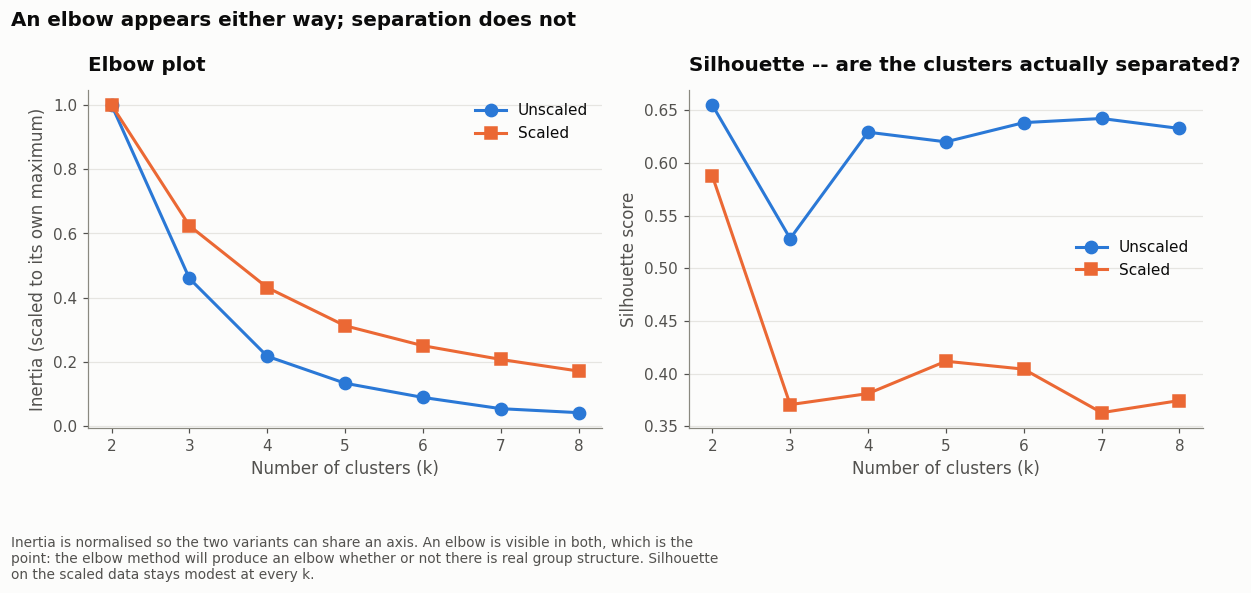

In [3]:
scaled_features = StandardScaler().fit_transform(year[CLUSTER_FEATURES])
variants = {"Unscaled": year[CLUSTER_FEATURES].to_numpy(), "Scaled": scaled_features}

rows = []
for label, matrix in variants.items():
    for k in range(2, 9):
        model = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(matrix)
        rows.append(
            {
                "Variant": label,
                "k": k,
                "inertia": model.inertia_,
                "silhouette": silhouette_score(matrix, model.labels_),
            }
        )

selection = pd.DataFrame(rows)
selection.round(4).to_csv(RESULTS / "kmeans_selection.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for label, colour, marker in [("Unscaled", plotting.BLUE, "o"), ("Scaled", plotting.ORANGE, "s")]:
    subset = selection[selection["Variant"] == label]
    axes[0].plot(
        subset["k"], subset["inertia"] / subset["inertia"].max(),
        marker=marker, color=colour, label=label,
    )
    axes[1].plot(subset["k"], subset["silhouette"], marker=marker, color=colour, label=label)

axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (scaled to its own maximum)")
axes[0].set_title("Elbow plot")
axes[0].legend()
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette -- are the clusters actually separated?")
axes[1].legend()
fig.suptitle(
    "An elbow appears either way; separation does not",
    x=0.0, ha="left", fontsize=13, fontweight="semibold", color=plotting.INK,
)
plotting.caption(
    fig,
    "Inertia is normalised so the two variants can share an axis. An elbow is visible in both, "
    "which is the point: the elbow method will produce an elbow whether or not there is real "
    "group structure. Silhouette on the scaled data stays modest at every k.",
    y=-0.08,
)
fig.tight_layout()
plotting.save_fig(fig, "15_kmeans_selection")
plt.show()

## 4.3 What the clusters actually are

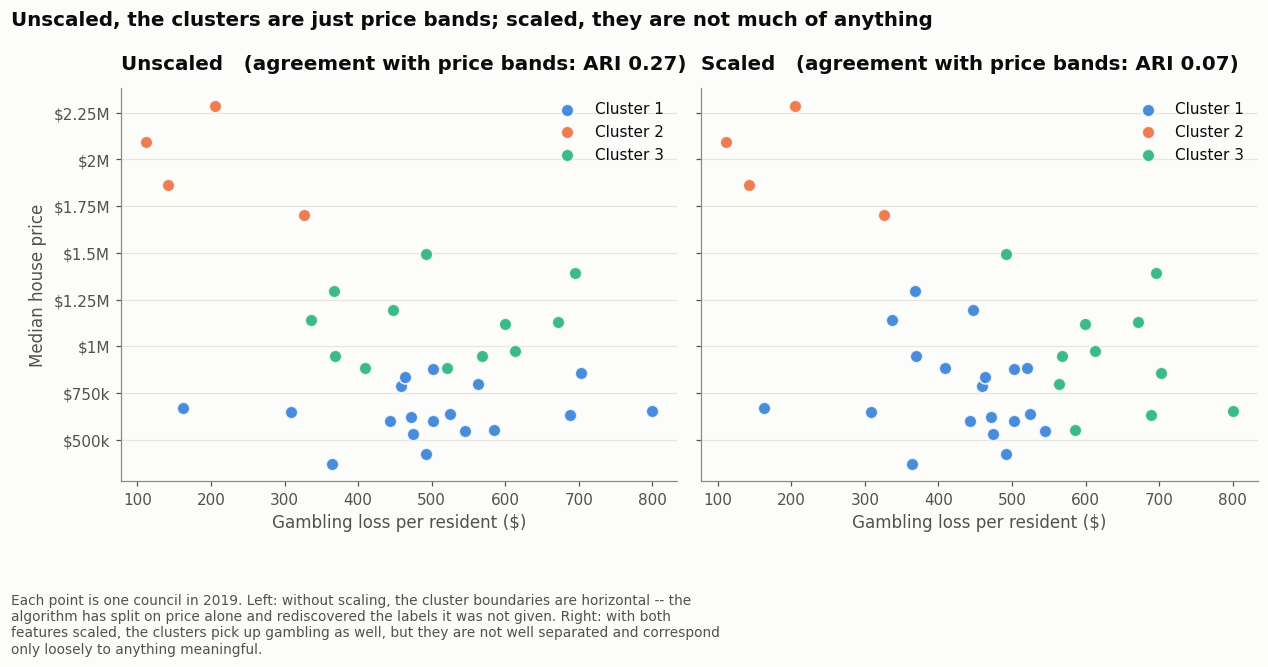

In [4]:
K = 3
fitted = {}
for label, matrix in variants.items():
    model = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(matrix)
    fitted[label] = model.labels_

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), sharey=True)
for ax, (label, labels) in zip(axes, fitted.items()):
    for cluster in range(K):
        mask = labels == cluster
        ax.scatter(
            year.loc[mask, "EGM Rate"], year.loc[mask, "Weighted House Price"],
            s=70, color=plotting.SERIES[cluster], alpha=0.85,
            edgecolor=plotting.SURFACE, linewidth=1.2,
            label=f"Cluster {cluster + 1}",
        )
    ari = adjusted_rand_score(year["Price Level"], labels)
    ax.set_title(f"{label}   (agreement with price bands: ARI {ari:.2f})")
    ax.set_xlabel("Gambling loss per resident ($)")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Median house price")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(plotting.thousands))

fig.suptitle(
    "Unscaled, the clusters are just price bands; scaled, they are not much of anything",
    x=0.0, ha="left", fontsize=13, fontweight="semibold", color=plotting.INK,
)
plotting.caption(
    fig,
    "Each point is one council in 2019. Left: without scaling, the cluster boundaries are "
    "horizontal -- the algorithm has split on price alone and rediscovered the labels it was "
    "not given. Right: with both features scaled, the clusters pick up gambling as well, but "
    "they are not well separated and correspond only loosely to anything meaningful.",
    y=-0.08,
)
fig.tight_layout()
plotting.save_fig(fig, "14_kmeans_unscaled_vs_scaled")
plt.show()

In [5]:
# The decisive test: cluster on the price column ALONE, and compare against the
# unscaled two-feature clustering. If they agree perfectly, the gambling feature
# contributed nothing and the "2-D" clustering was one-dimensional all along.
price_only = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(
    year[["Weighted House Price"]]
)

rows = []
for label, labels in fitted.items():
    rows.append(
        {
            "Variant": label,
            "k": K,
            "Silhouette": silhouette_score(variants[label], labels),
            "ARI vs price bands": adjusted_rand_score(year["Price Level"], labels),
            "ARI vs price-only clustering": adjusted_rand_score(price_only.labels_, labels),
        }
    )
agreement = pd.DataFrame(rows)
agreement.round(4).to_csv(RESULTS / "kmeans_agreement.csv", index=False)
agreement.round(4)

,Variant,k,Silhouette,ARI vs price bands,ARI vs price-only clustering
0,Unscaled,3,0.5282,0.2663,1.0000
1,Scaled,3,0.3706,0.0733,0.2285


The last column is the decisive one.

**Unscaled**, the two-feature clustering agrees *perfectly* with a clustering
that used the house price column and nothing else: adjusted Rand index 1.00. The
gambling feature contributed literally nothing. What looked like a
two-dimensional analysis was one-dimensional, and the clusters were simply price
terciles under another name. (Their agreement with the report's Low/Medium/High
bands is only moderate, but that is just because K-means picked different cut
points -- not because it used any other information.)

**Scaled**, the clustering finally uses both features, and its agreement with
the price-only version drops accordingly. But the silhouette score stays low:
the groups are not well separated, which is what it looks like when points lie
along a continuum rather than falling into natural clumps.

## 4.4 Conclusion: the right call, for a slightly different reason

Abandoning K-means here was correct, and the re-run supports it with numbers
rather than with an impression.

What I got right at the time: there is no useful cluster structure in this data,
and continuing to tune the method would have been wasted effort.

What I had slightly wrong: I attributed it to "the y-axis being dependent on x".
The actual mechanism is that the two features differ in variance by about seven
orders of magnitude, so unscaled K-means was silently clustering on house price
alone. Fixing that -- which is a one-line change -- does not rescue the method.
It just replaces a degenerate answer with a weakly separated one.

That is the useful lesson, and it is why this notebook is kept rather than
quietly deleted. The councils of Victoria do not fall into natural groups in
(price, gambling, crime) space; they lie along a continuum. Clustering is the
wrong tool for a continuum, and no amount of preprocessing changes that. The
right tools were the supervised ones in notebooks 2 and 3 -- which, as it turned
out, had their own and more serious problem.